# Itau Quant Challenge 2025 - Pipeline End-to-End

Este notebook executa o processo completo do repositorio, explicando cada etapa e salvando artefatos em `reports/`.

Etapas:
- Carregar configuracao e dados
- Rodar backtest base e exibir KPIs
- Walk-forward validation
- Heatmaps de sensibilidade de parametros
- Stress de custos de transacao
- Capacity curve
- (Opcional) PDF consolidado do relatorio


In [1]:
import features, importlib, sys
print("features from:", features.__file__)
import features.tda as tda, features.factors as fac
print("has get_alphas_from_cfg?", hasattr(fac, "get_alphas_from_cfg"))
print("TFIParams.from_config?", hasattr(tda.TFIParams, "from_config"))
print(sys.path[:3])


features from: C:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\src\features\__init__.py
has get_alphas_from_cfg? True
TFIParams.from_config? True
['C:\\Program Files\\Python312\\python312.zip', 'C:\\Program Files\\Python312\\DLLs', 'C:\\Program Files\\Python312\\Lib']


In [2]:
# Setup
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

import os; os.environ["REGIME_GAIN"] = "2"
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'src').exists(), 'Execute a partir do repo root ou da pasta notebooks/'
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
%matplotlib inline

REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print('Repo root:', ROOT)
print('Reports dir:', REPORTS_DIR)

Repo root: c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025
Reports dir: c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports


## Configuracao
Carrega o YAML de configuracao base do projeto.

In [3]:
from dataio.config import load_config

CONFIG_PATH = ROOT / 'configs' / 'base.yaml'
cfg = load_config(str(CONFIG_PATH))
print('Config carregada:', CONFIG_PATH)
print('Datas:', cfg.get('dates'))
cfg

Config carregada: c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\configs\base.yaml
Datas: {'start': datetime.date(2019, 9, 4), 'end': datetime.date(2022, 10, 6)}


{'portfolio': {'method': 'hrp',
  'periphery_bias_lambda': 0.0,
  'expected_returns': {'enabled': True,
   'max_tilt': 0.03,
   'min_signal_z': 0.0,
   'regime_gate': 0.0,
   'risk_aversion': 2.5,
   'long_only': True}},
 'data': {'source': 'local_csv'},
 'paths': {'data': './data',
  'reports': './reports',
  'artifacts': './artifacts'},
 'seeds': 42,
 'dates': {'start': datetime.date(2019, 9, 4),
  'end': datetime.date(2022, 10, 6)},
 'tda': {'delay': 1,
  'dim': 2,
  'n_cubes': 2,
  'overlap': 0.2,
  'epsilon': None,
  'min_samples': 4,
  'window': 168,
  'eps_quantile': 0.15,
  'smooth_span': 10,
  'n_jobs': -1},
 'tda_ph': {'enabled': True,
  'window': 50,
  'homology_dim': 1,
  'norm': 'l2',
  'smooth_span': 10,
  'zscore_lookback': 250,
  'alert_sigma': 1.0,
  'riskoff_sigma': 2.0},
 'mapper': {'enabled': True,
  'lens': 'pca_umap',
  'n_cubes': 4,
  'overlap': 0.5,
  'eps_quantile': 0.15,
  'min_cluster_size': 4,
  'epsilon_adaptive': True},
 'factors': {'alphas': ['momentum', 

## Dados
Carrega o painel de mercado. Se o `get_panel` falhar, cai para dados sinteticos. Exibe um preview e o intervalo de datas.

In [4]:
from main import _load_panel as _load_panel

panel = _load_panel(cfg)
date_level = 'date' if 'date' in panel.index.names else panel.index.names[0]
print('Panel shape:', panel.shape)
print('Date range:', panel.index.get_level_values(date_level).min(), '->', panel.index.get_level_values(date_level).max())
panel.sort_index().head()

Panel shape: (48252, 2)
Date range: 2019-09-04 00:00:00 -> 2022-10-06 00:00:00


close       volume
date       asset                    
2019-09-04 ABEV3  18.80  284647972.0
           AZUL4  47.11  134194134.0
           B3SA3  44.63  376593215.0
           BBAS3  45.86  319637030.0
           BBDC3  29.41   63840289.0

## Backtest Base
Executa o backtest principal, plota a equity e salva artefatos em `reports/`.

Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)
Kill switch triggered on 2020-02-17 (vol=0.1308)
Kill switch triggered on 2020-06-17 (vol=0.1294)
Kill switch triggered on 2020-10-20 (vol=0.1288)
Kill switch triggered on 2021-02-23 (vol=0.1316)
Kill switch triggered on 2021-06-02 (vol=0.1305)
Kill switch triggered on 2021-07-30 (vol=0.1394)
Kill switch triggered on 2021-11-16 (vol=0.1290)
Kill switch triggered on 2022-01-03 (vol=0.1371)
Kill swi

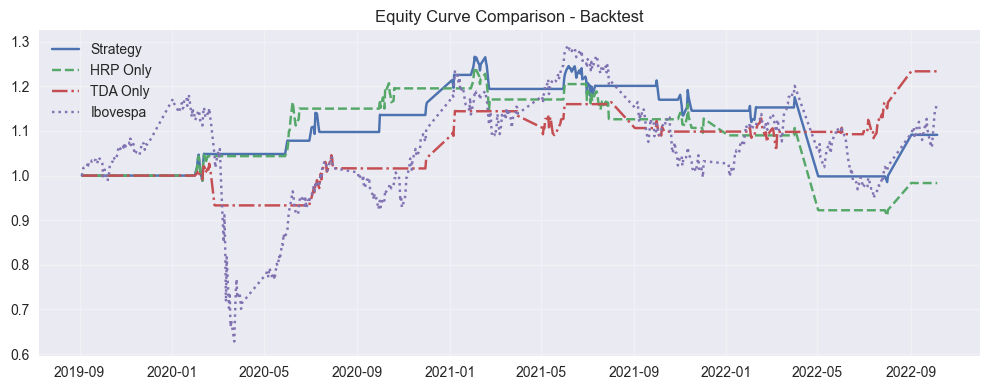

**KPIs - Backtest (Strategy vs HRP Only vs TDA Only vs Ibovespa)**

,CAGR,Sharpe,Sortino,Vol,MaxDD,Calmar,HitRate,Turnover
Strategy,0.037834,0.319865,0.142345,0.155342,-0.221937,0.17047,0.504854,0.019761
HRP Only,-0.007139,0.03739,0.015852,0.157171,-0.267913,-0.026648,0.480392,0.016863
TDA Only,0.09337,0.806275,0.48619,0.119859,-0.091117,1.024729,0.571429,0.015422
Ibovespa,0.06575,0.360042,0.409387,0.346214,-0.46816,0.140445,0.532095,<NA>


Comparacao salva em: C:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\equity_curve_comparison.png


In [5]:
from copy import deepcopy
from backtest.engine import run_backtest
from reports import plot_equity_curves, table_kpis

bt = run_backtest(cfg, panel=panel)
equity = bt['equity_curve']
returns = equity.pct_change().dropna()

hrp_cfg = deepcopy(cfg)
hrp_portfolio = hrp_cfg.setdefault('portfolio', {})
hrp_portfolio['method'] = 'hrp_only'
hrp_portfolio.setdefault('hrp_only_regime_value', 0.5)

tda_cfg = deepcopy(cfg)
tda_cfg.setdefault('portfolio', {})['method'] = 'tda_only'

bt_hrp = run_backtest(hrp_cfg, panel=panel)
equity_hrp = bt_hrp['equity_curve']
returns_hrp = equity_hrp.pct_change().dropna()

bt_tda = run_backtest(tda_cfg, panel=panel)
equity_tda = bt_tda['equity_curve']
returns_tda = equity_tda.pct_change().dropna()

ibov_path = (ROOT / 'data' / 'benchmark' / 'ibovespa_index_b3.csv').resolve()
ibov_prices = (
    pd.read_csv(ibov_path, parse_dates=['date'], index_col='date')['close']
    .sort_index()
)
ibov_prices_aligned = ibov_prices.reindex(equity.index).ffill()
if ibov_prices_aligned.isna().all():
    raise ValueError('Ibovespa benchmark does not overlap with backtest dates.')
ibov_equity = (ibov_prices_aligned / ibov_prices_aligned.iloc[0]).rename('Ibovespa')
ibov_returns = ibov_equity.pct_change().fillna(0.0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(equity.index, equity.values, label='Strategy')
ax.plot(equity_hrp.index, equity_hrp.values, label='HRP Only', linestyle='--')
ax.plot(equity_tda.index, equity_tda.values, label='TDA Only', linestyle='-.')
ax.plot(ibov_equity.index, ibov_equity.values, label='Ibovespa', linestyle=':')
ax.set_title('Equity Curve Comparison - Backtest')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

kpi = table_kpis({
    'Strategy': {
        'equity_curve': equity,
        'returns': returns,
        'weights': bt.get('daily_positions')
    },
    'HRP Only': {
        'equity_curve': equity_hrp,
        'returns': returns_hrp,
        'weights': bt_hrp.get('daily_positions')
    },
    'TDA Only': {
        'equity_curve': equity_tda,
        'returns': returns_tda,
        'weights': bt_tda.get('daily_positions')
    },
    'Ibovespa': {
        'equity_curve': ibov_equity,
        'returns': ibov_returns,
        'weights': None
    }
})
display(Markdown('**KPIs - Backtest (Strategy vs HRP Only vs TDA Only vs Ibovespa)**'))
display(kpi)

comparison_png = plot_equity_curves(
    {
        'Strategy': equity,
        'HRP Only': equity_hrp,
        'TDA Only': equity_tda,
        'Ibovespa': ibov_equity,
    },
    filename='equity_curve_comparison.png'
)
print('Comparacao salva em:', comparison_png)


,value
CAGR_Strategy,0.037834
CAGR_Ibov,0.065750
Excess_CAGR,-0.027917
Alpha_ann,0.030521
Beta,0.153097
TrackingError,0.327495
InformationRatio,-0.229154
MaxDD_Strategy,-0.221937
MaxDD_Ibov,-0.468160
MonthlyHitRate,0.394737


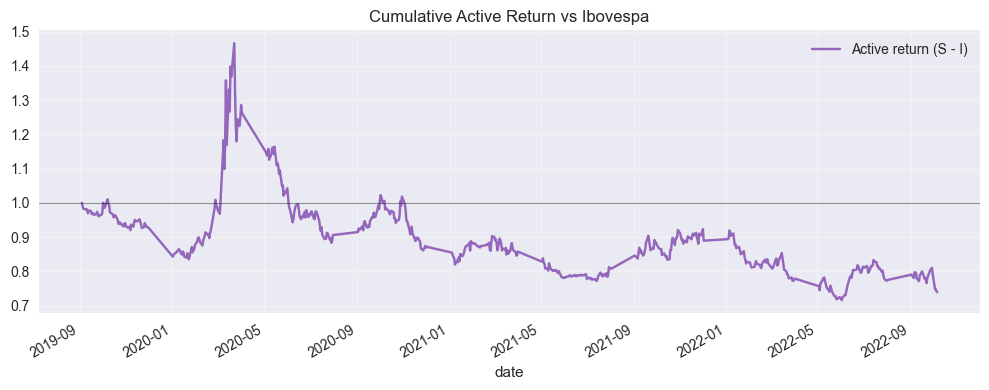

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

try:
    ibov_series = ibov_prices.copy()
except NameError:
    project_root = Path.cwd().resolve().parent
    ibov_path = project_root / 'data' / 'benchmark' / 'ibovespa_index_b3.csv'
    ibov_series = (
        pd.read_csv(ibov_path, parse_dates=['date'], index_col='date')['close']
        .sort_index()
    )

idx = equity.index.intersection(ibov_series.index)
if idx.empty:
    raise ValueError('Ibovespa series does not overlap with strategy equity dates.')

eq = equity.loc[idx].ffill()
ib_prices = ibov_series.loc[idx].ffill()

try:
    ib = ibov_equity.reindex(idx).ffill()
except NameError:
    ib = (ib_prices / ib_prices.iloc[0]).rename('Ibovespa')

r_s = eq.pct_change().fillna(0.0)
try:
    r_b = ibov_returns.reindex(idx).fillna(0.0)
except NameError:
    r_b = ib.pct_change().fillna(0.0)
r_ex = r_s - r_b

ann = 252
te = r_ex.std(ddof=0) * np.sqrt(ann)
ir = (r_ex.mean() / r_ex.std(ddof=0)) * np.sqrt(ann) if r_ex.std(ddof=0) > 0 else np.nan
beta = (r_s.cov(r_b) / r_b.var()) if r_b.var() > 0 else np.nan
alpha_ann = (r_s.mean() - beta * r_b.mean()) * ann if beta == beta else np.nan

cagr_s = (eq.iloc[-1] / eq.iloc[0]) ** (ann / len(r_s)) - 1
cagr_b = (ib.iloc[-1] / ib.iloc[0]) ** (ann / len(r_b)) - 1
dd_s = (eq / eq.cummax() - 1.0).min()
dd_b = (ib / ib.cummax() - 1.0).min()
hit_m = (r_s.resample('M').sum() > r_b.resample('M').sum()).mean()

summary = pd.Series({
    'CAGR_Strategy': cagr_s,
    'CAGR_Ibov': cagr_b,
    'Excess_CAGR': cagr_s - cagr_b,
    'Alpha_ann': alpha_ann,
    'Beta': beta,
    'TrackingError': te,
    'InformationRatio': ir,
    'MaxDD_Strategy': dd_s,
    'MaxDD_Ibov': dd_b,
    'MonthlyHitRate': hit_m,
}).to_frame('value')
display(summary)

active_curve = (1.0 + r_ex).cumprod()
ax = active_curve.plot(figsize=(10, 4), color='tab:purple', label='Active return (S - I)')
ax.axhline(1.0, color='black', lw=0.8, alpha=0.4)
ax.set_title('Cumulative Active Return vs Ibovespa')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Walk-Forward Validation
Executa validacao walk-forward (2 anos in-sample / 6 meses out-of-sample). Mostra equity e KPIs agregados.

In [ ]:
# from validation import run_walk_forward

# wf = run_walk_forward(cfg, panel)
# walk_equity = wf['equity_curve']

# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(walk_equity.index, walk_equity.values, color='#ff7f0e', label='Walk-Forward')
# ax.axhline(1.0, color='black', linewidth=0.8, alpha=0.3)
# ax.set_title('Equity - Walk-Forward')
# ax.grid(True, alpha=0.3)
# ax.legend()
# plt.tight_layout()
# plt.show()

# display(Markdown('**KPIs - Walk-Forward**'))
# display(pd.DataFrame(wf['kpis'], index=['Valor']).T)

# windows_df = pd.DataFrame(wf['windows'])
# display(Markdown('**Janelas Walk-Forward (amostra)**'))
# display(windows_df.head())

### Funcoes auxiliares para grids customizados
Utilidades genericas para montar grids 2D de parametros (kill switch, caps do HRP, etc.), extraindo metricas financeiras e salvando os artefatos em `reports/parameter_sweeps`.

In [9]:
from copy import deepcopy
from pathlib import Path

reports_dir = REPORTS_DIR / "parameter_sweeps"
reports_dir.mkdir(parents=True, exist_ok=True)

def _set_nested(cfg_dict, dotted_key, value):
    parts = dotted_key.split(".")
    node = cfg_dict
    for key in parts[:-1]:
        if key not in node or not isinstance(node[key], dict):
            node[key] = {}
        node = node[key]
    node[parts[-1]] = value

def _extract_metrics(kpis):
    cagr = kpis.get("annual_return")
    sharpe_val = kpis.get("sharpe")
    vol = kpis.get("annual_vol")
    maxdd = kpis.get("max_drawdown")
    calmar = np.nan
    if maxdd not in (None, 0) and np.isfinite(maxdd) and cagr is not None and np.isfinite(cagr):
        calmar = cagr / abs(maxdd) if abs(maxdd) > 0 else np.nan
    return {
        "cagr": cagr,
        "sharpe": sharpe_val,
        "vol": vol,
        "max_drawdown": maxdd,
        "calmar": calmar,
    }

def run_two_param_heatmaps(cfg_base, panel_data, grid, report_prefix, plot_metrics=("sharpe", "max_drawdown")):
    if len(grid) != 2:
        raise ValueError("Grid precisa ter exatamente dois parametros para heatmap.")
    axes = list(grid.keys())
    axis_values = [list(grid[axes[0]]), list(grid[axes[1]])]
    metric_surfaces = {metric: np.full((len(axis_values[0]), len(axis_values[1])), np.nan) for metric in plot_metrics}
    records = []
    for i, val_x in enumerate(axis_values[0]):
        for j, val_y in enumerate(axis_values[1]):
            cfg_run = deepcopy(cfg_base)
            _set_nested(cfg_run, axes[0], val_x)
            _set_nested(cfg_run, axes[1], val_y)
            print(f" - Backtest {report_prefix} | {axes[0]}={val_x}, {axes[1]}={val_y}")
            result = run_backtest(cfg_run, panel=panel_data)
            metrics = _extract_metrics(result["kpis"])
            record = {axes[0]: val_x, axes[1]: val_y, **metrics}
            records.append(record)
            for metric in plot_metrics:
                metric_surfaces[metric][i, j] = metrics.get(metric)
    results_df = pd.DataFrame(records)
    csv_path = reports_dir / f"{report_prefix}_results.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"Resultados salvos em {csv_path}")
    heatmap_paths = {}
    for metric, surface in metric_surfaces.items():
        fig, ax = plt.subplots(figsize=(7, 5))
        im = ax.imshow(surface, origin="lower", aspect="auto", cmap="viridis")
        ax.set_xticks(range(len(axis_values[1])))
        ax.set_xticklabels([str(v) for v in axis_values[1]])
        ax.set_yticks(range(len(axis_values[0])))
        ax.set_yticklabels([str(v) for v in axis_values[0]])
        ax.set_xlabel(axes[1])
        ax.set_ylabel(axes[0])
        ax.set_title(f"{metric.title()} - {report_prefix}")
        fig.colorbar(im, ax=ax)
        fig.tight_layout()
        out_path = reports_dir / f"{report_prefix}_{metric}_heatmap.png"
        fig.savefig(out_path, dpi=150)
        plt.close(fig)
        heatmap_paths[metric] = out_path
    return results_df, heatmap_paths


## TDA - Heatmaps de Sensibilidade
Explora combinacoes dos hiperparametros de `tda_ph` e `mapper`. Cada grid roda o backtest com os novos parametros e renderiza as figuras diretamente aqui para comparacao rapida.

Executando heatmap TDA para window x n_cubes: {'window': [42, 63, 84], 'n_cubes': [2, 4, 6]}


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)
Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill swi

Executando heatmap TDA para overlap x eps_quantile: {'overlap': [0.2, 0.35, 0.5], 'eps_quantile': [0.1, 0.15, 0.2]}


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)
Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill swi

Executando heatmap TDA para delay x dim: {'delay': [1, 2, 3], 'dim': [2, 3]}


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)
Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill swi

**Heatmaps salvos para as combinacoes de TDA**

,grid,metric,path
0,window x n_cubes,Sharpe,C:\Users\Cockles\Documents\GitHub\itau-quant-c...
1,window x n_cubes,Vol,C:\Users\Cockles\Documents\GitHub\itau-quant-c...
2,overlap x eps_quantile,Sharpe,C:\Users\Cockles\Documents\GitHub\itau-quant-c...
3,overlap x eps_quantile,Vol,C:\Users\Cockles\Documents\GitHub\itau-quant-c...
4,delay x dim,Sharpe,C:\Users\Cockles\Documents\GitHub\itau-quant-c...
5,delay x dim,Vol,C:\Users\Cockles\Documents\GitHub\itau-quant-c...


**window x n_cubes**

*Sharpe* (`C:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\heatmap_sharpe_20251009_203244.png`)

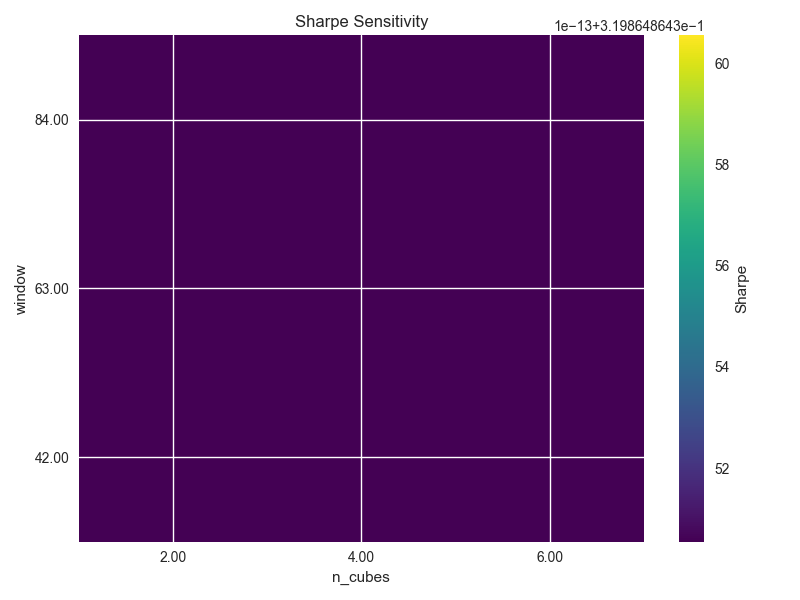

*Vol* (`C:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\heatmap_vol_20251009_203244.png`)

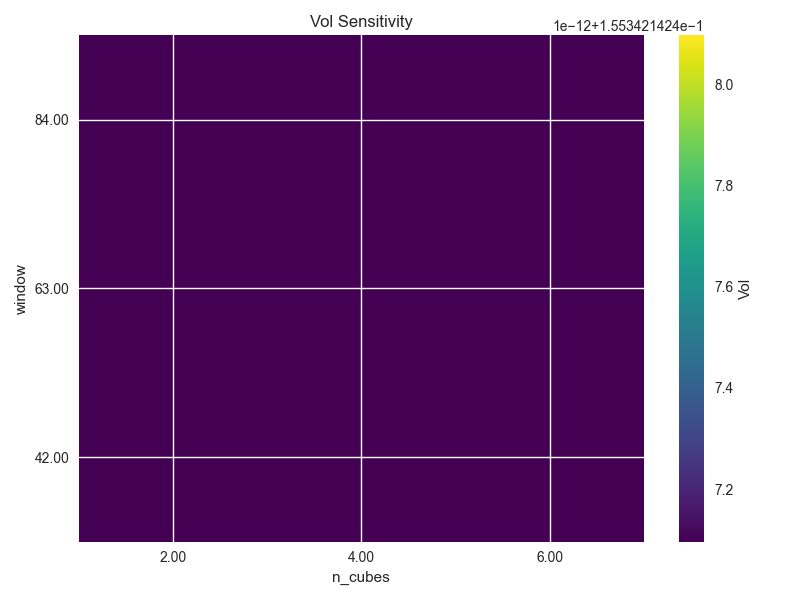

**overlap x eps_quantile**

*Sharpe* (`C:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\heatmap_sharpe_20251009_203446.png`)

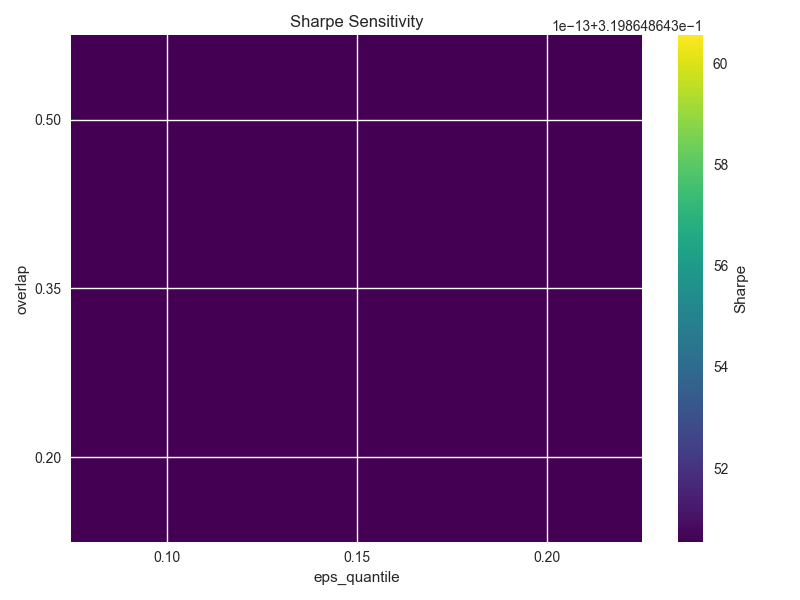

*Vol* (`C:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\heatmap_vol_20251009_203446.png`)

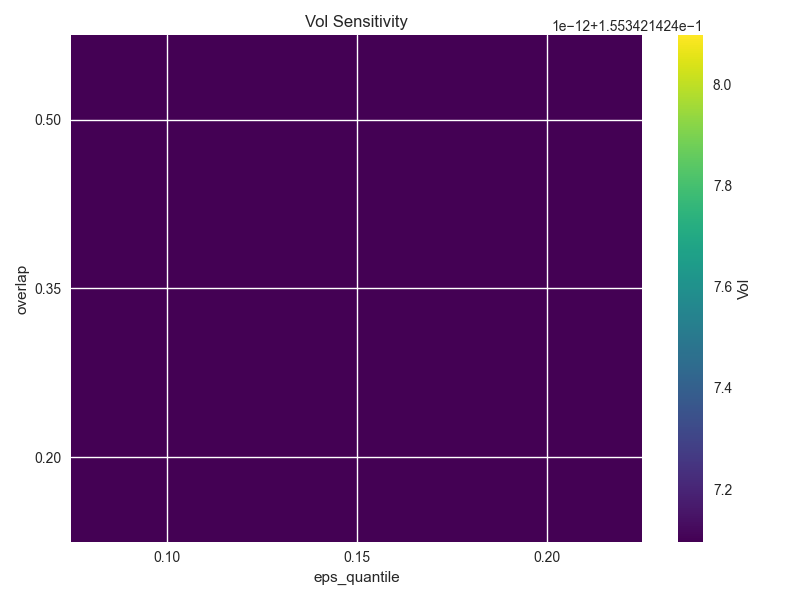

**delay x dim**

*Sharpe* (`C:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\heatmap_sharpe_20251009_203607.png`)

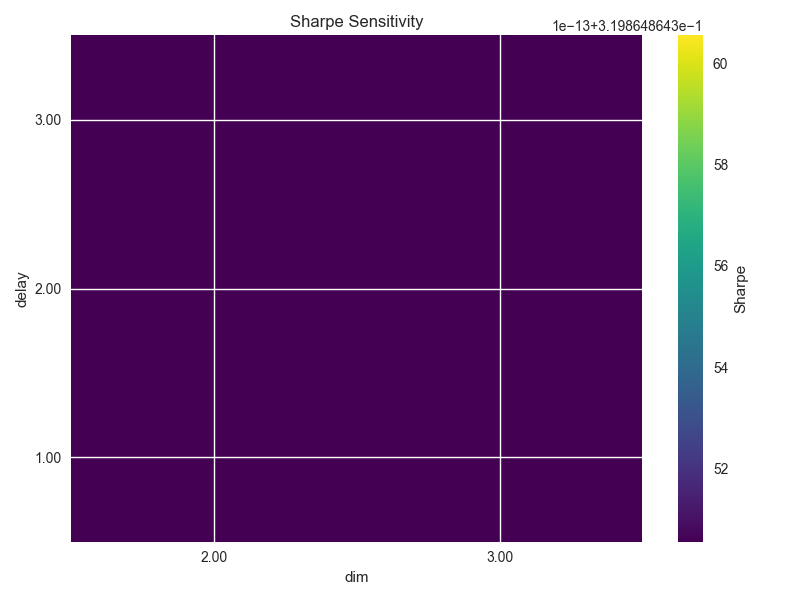

*Vol* (`C:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\heatmap_vol_20251009_203608.png`)

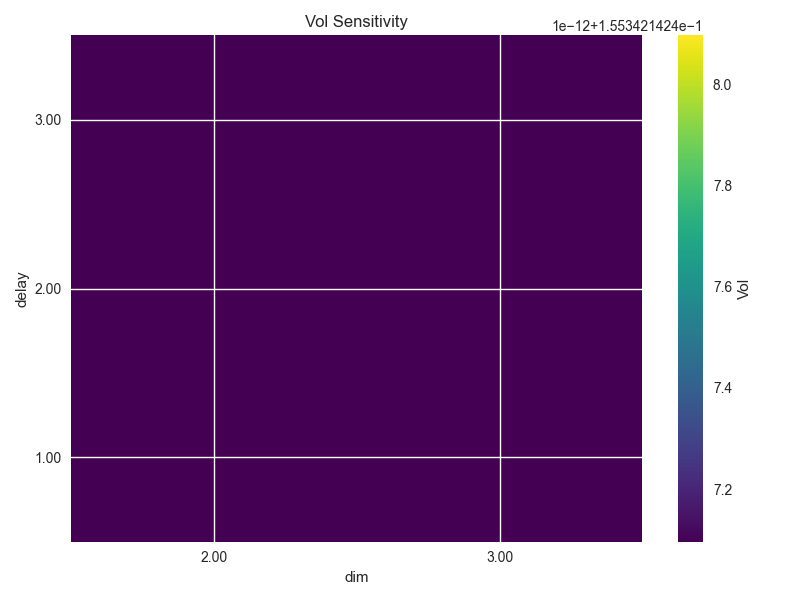

In [8]:
tda_grids = [
    {"name": "tda_ph.window vs tda_ph.smooth_span", "grid": {"tda_ph.window": [42, 63, 84], "tda_ph.smooth_span": [5, 10, 15]}},
    {"name": "mapper.n_cubes vs mapper.overlap", "grid": {"mapper.n_cubes": [2, 4, 6], "mapper.overlap": [0.20, 0.35, 0.50]}},
    {"name": "mapper.overlap vs mapper.eps_quantile", "grid": {"mapper.overlap": [0.20, 0.35, 0.50], "mapper.eps_quantile": [0.10, 0.15, 0.20]}},
]

tda_runs = {}
for entry in tda_grids:
    name = entry["name"]
    grid = entry["grid"]
    prefix = name.replace(" ", "_").replace(".", "-").replace("/", "-")
    display(Markdown(f"**Grid {name}** - parametros {list(grid.keys())}"))
    results_df, heatmaps = run_two_param_heatmaps(
        cfg,
        panel,
        grid,
        report_prefix=f"tda_{prefix}",
        plot_metrics=("sharpe", "max_drawdown"),
    )
    tda_runs[name] = {"results": results_df, "heatmaps": heatmaps}
    display(results_df.sort_values("sharpe", ascending=False).head())
    for metric, path in heatmaps.items():
        display(Markdown(f"{metric.title()} heatmap: `{path}`"))
        display(Image(filename=str(path), width=420))

tda_summary = pd.DataFrame(
    [
        {"grid": name, "metric": metric, "path": str(path)}
        for name, payload in tda_runs.items()
        for metric, path in payload["heatmaps"].items()
    ]
)
display(Markdown("**Arquivos de heatmap (TDA)**"))
display(tda_summary)


## Kill Switch - Sensibilidade de Parametros
Varre combinacoes relevantes dos limites de drawdown/vol e da janela de monitoramento para verificar impacto em Sharpe e MaxDD.

**Grid Mdd Vs Vol** - parametros ['risk.mdd_thres', 'risk.vol_mult']

 - Backtest kill_switch_mdd_vs_vol | risk.mdd_thres=-0.12, risk.vol_mult=1.6


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


 - Backtest kill_switch_mdd_vs_vol | risk.mdd_thres=-0.12, risk.vol_mult=1.8


Kill switch triggered on 2020-02-19 (vol=0.1585)
Kill switch triggered on 2020-07-17 (vol=0.1447)
Kill switch triggered on 2021-01-04 (vol=0.1702)
Kill switch triggered on 2021-07-06 (vol=0.1487)
Kill switch triggered on 2021-10-19 (vol=0.1565)
Kill switch triggered on 2021-11-08 (vol=0.1447)
Kill switch triggered on 2022-03-09 (vol=0.1613)
Kill switch triggered on 2022-09-02 (vol=0.2143)


...

 - Backtest kill_switch_mdd_vs_vol | risk.mdd_thres=-0.18, risk.vol_mult=2.0


Kill switch triggered on 2020-02-21 (vol=0.1623)
Kill switch triggered on 2020-06-01 (vol=0.1631)
Kill switch triggered on 2020-07-20 (vol=0.1629)
Kill switch triggered on 2020-10-01 (vol=0.1680)
Kill switch triggered on 2021-01-15 (vol=0.1624)
Kill switch triggered on 2021-02-19 (vol=0.1606)
Kill switch triggered on 2021-07-12 (vol=0.1613)
Kill switch triggered on 2021-09-02 (vol=0.1947)
Kill switch triggered on 2021-11-16 (vol=0.1679)
Kill switch triggered on 2022-03-07 (vol=0.1663)
Kill switch triggered on 2022-05-02 (mdd=-0.1972,vol=0.3377)
Kill switch triggered on 2022-09-02 (vol=0.1915)


Resultados salvos em c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\kill_switch_mdd_vs_vol_results.csv


,risk.mdd_thres,risk.vol_mult,cagr,sharpe,vol,max_drawdown,calmar
1,-0.12,1.8,0.182812,1.305717,0.140009,-0.146815,1.245190
4,-0.15,1.8,0.182812,1.305717,0.140009,-0.146815,1.245190
7,-0.18,1.8,0.182812,1.305717,0.140009,-0.146815,1.245190
2,-0.12,2.0,0.069987,0.405810,0.172462,-0.272516,0.256818
5,-0.15,2.0,0.069987,0.405810,0.172462,-0.272516,0.256818


Sharpe heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\kill_switch_mdd_vs_vol_sharpe_heatmap.png`

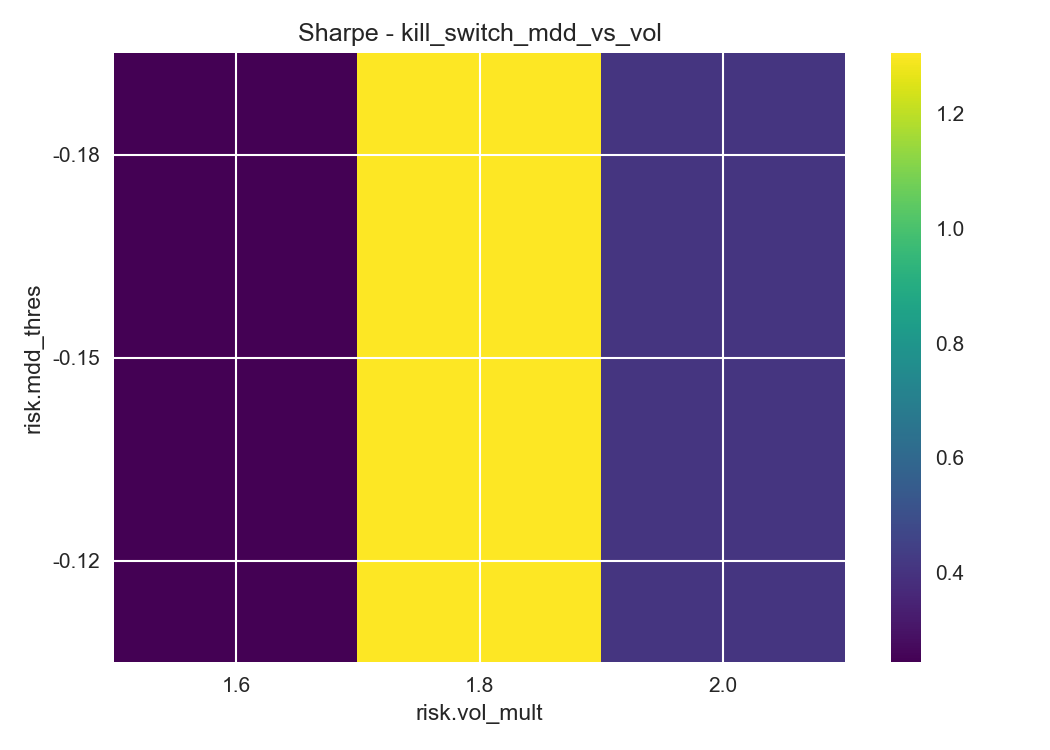

Max_Drawdown heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\kill_switch_mdd_vs_vol_max_drawdown_heatmap.png`

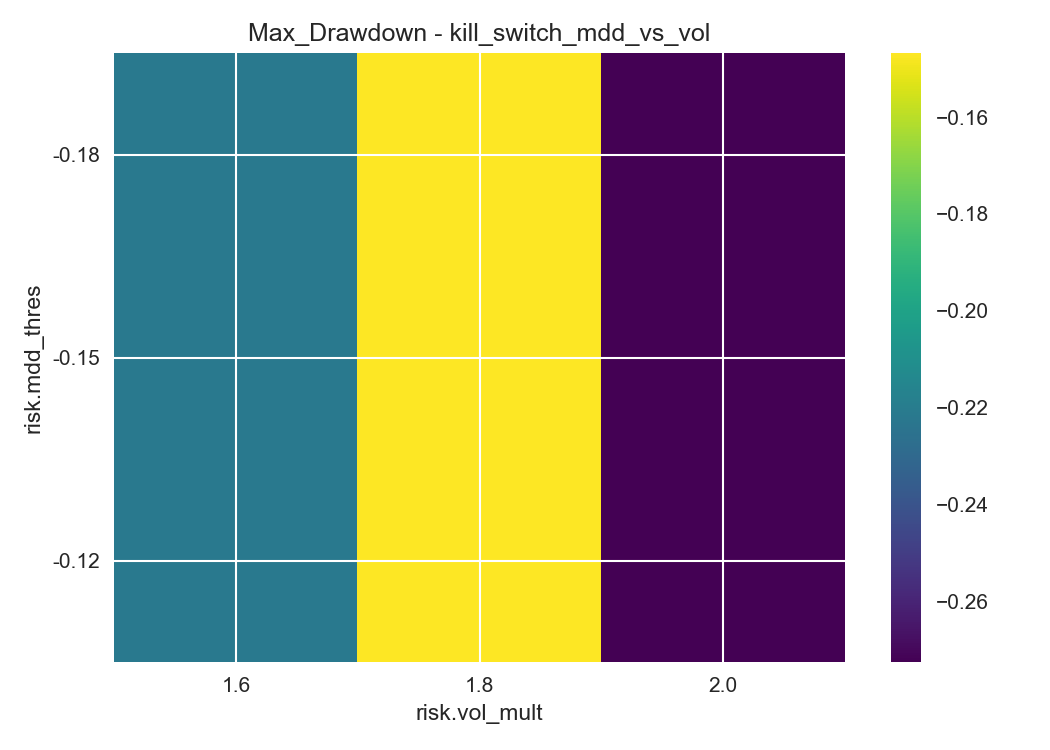

**Grid Lookback Vs Cooldown** - parametros ['risk.mdd_lookback', 'risk.cooldown_days']

 - Backtest kill_switch_lookback_vs_cooldown | risk.mdd_lookback=45, risk.cooldown_days=10


Kill switch triggered on 2020-02-11 (vol=0.1445)
Kill switch triggered on 2020-06-16 (vol=0.1282)
Kill switch triggered on 2020-10-06 (vol=0.1353)
Kill switch triggered on 2021-02-23 (vol=0.1304)
Kill switch triggered on 2021-07-06 (vol=0.1298)
Kill switch triggered on 2021-10-19 (vol=0.1507)
Kill switch triggered on 2022-03-07 (vol=0.1594)
Kill switch triggered on 2022-06-13 (mdd=-0.1358,vol=0.1418)
Kill switch triggered on 2022-10-03 (vol=0.1406)


 - Backtest kill_switch_lookback_vs_cooldown | risk.mdd_lookback=45, risk.cooldown_days=21


Kill switch triggered on 2020-02-11 (vol=0.1445)
Kill switch triggered on 2020-06-16 (vol=0.1282)
Kill switch triggered on 2020-10-06 (vol=0.1353)
Kill switch triggered on 2021-02-23 (vol=0.1304)
Kill switch triggered on 2021-07-06 (vol=0.1298)
Kill switch triggered on 2021-10-19 (vol=0.1507)
Kill switch triggered on 2022-03-07 (vol=0.1594)
Kill switch triggered on 2022-06-13 (mdd=-0.1358,vol=0.1418)
Kill switch triggered on 2022-10-03 (vol=0.1406)


...

 - Backtest kill_switch_lookback_vs_cooldown | risk.mdd_lookback=90, risk.cooldown_days=30


Kill switch triggered on 2020-02-19 (vol=0.1298)
Kill switch triggered on 2020-09-18 (vol=0.1310)
Kill switch triggered on 2021-03-17 (vol=0.1316)
Kill switch triggered on 2021-10-29 (vol=0.1283)
Kill switch triggered on 2022-05-02 (mdd=-0.1551,vol=0.2581)


Resultados salvos em c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\kill_switch_lookback_vs_cooldown_results.csv


,risk.mdd_lookback,risk.cooldown_days,cagr,sharpe,vol,max_drawdown,calmar
3,60,10,0.037834,0.243405,0.155435,-0.221937,0.170470
4,60,21,0.037834,0.243405,0.155435,-0.221937,0.170470
5,60,30,0.037834,0.243405,0.155435,-0.221937,0.170470
0,45,10,-0.025337,-0.215970,0.117317,-0.238654,-0.106166
1,45,21,-0.025337,-0.215970,0.117317,-0.238654,-0.106166


Sharpe heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\kill_switch_lookback_vs_cooldown_sharpe_heatmap.png`

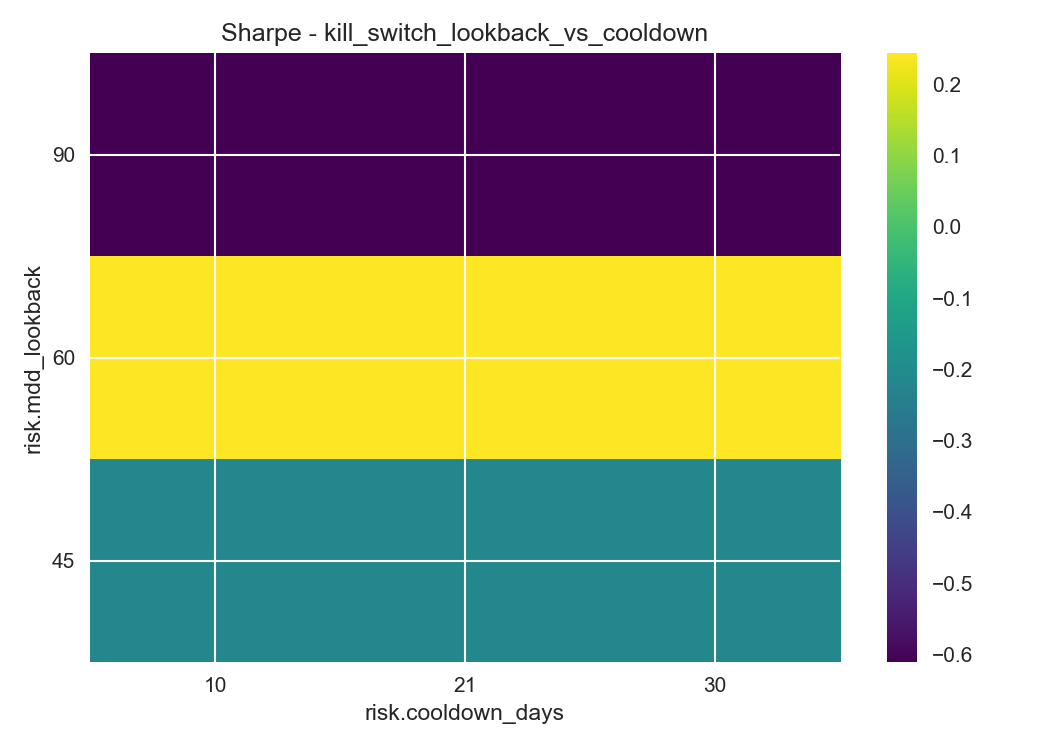

Max_Drawdown heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\kill_switch_lookback_vs_cooldown_max_drawdown_heatmap.png`

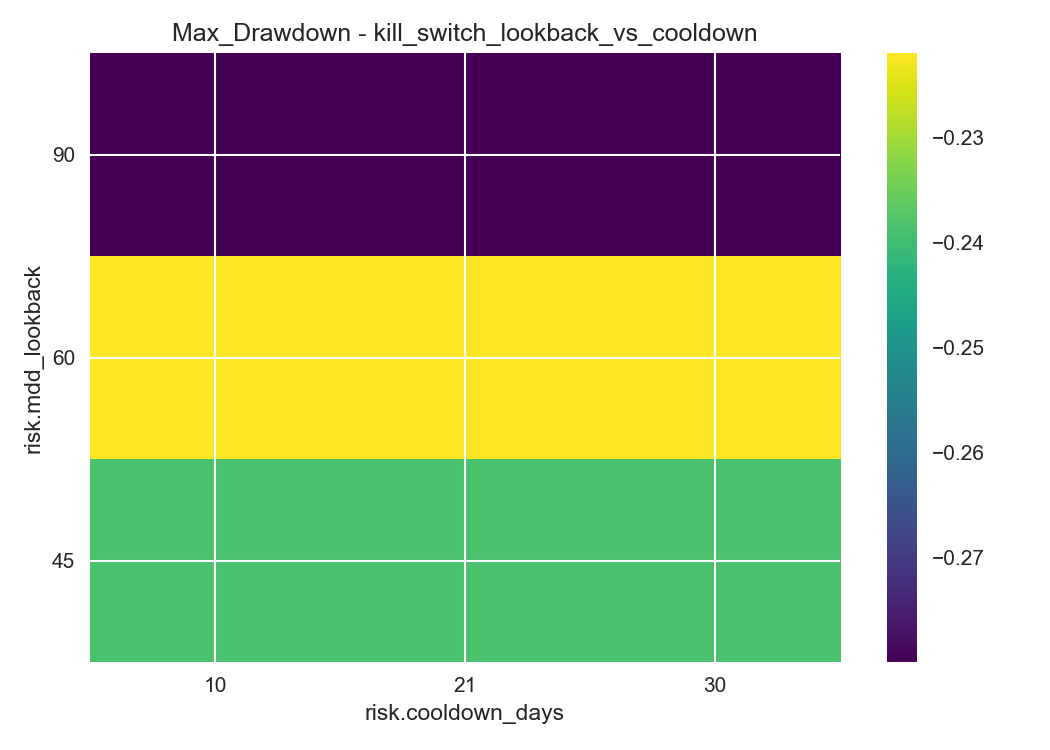

**Arquivos de heatmap do kill switch**

,grid,metric,path
0,mdd_vs_vol,sharpe,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
1,mdd_vs_vol,max_drawdown,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
2,lookback_vs_cooldown,sharpe,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
3,lookback_vs_cooldown,max_drawdown,c:\Users\Cockles\Documents\GitHub\itau-quant-c...


In [10]:
kill_switch_grids = {
    "mdd_vs_vol": {
        "risk.mdd_thres": [-0.12, -0.15, -0.18],
        "risk.vol_mult": [1.6, 1.8, 2.0],
    },
    "lookback_vs_cooldown": {
        "risk.mdd_lookback": [45, 60, 90],
        "risk.cooldown_days": [10, 21, 30],
    },
}

kill_switch_runs = {}
for label, grid in kill_switch_grids.items():
    prefix = f"kill_switch_{label}"
    friendly = label.replace("_", " " ).title()
    display(Markdown(f"**Grid {friendly}** - parametros {list(grid.keys())}"))
    results_df, heatmaps = run_two_param_heatmaps(
        cfg,
        panel,
        grid,
        report_prefix=prefix,
        plot_metrics=("sharpe", "max_drawdown")
    )
    kill_switch_runs[label] = {"results": results_df, "heatmaps": heatmaps}
    display(results_df.sort_values("sharpe", ascending=False).head())
    for metric, path in heatmaps.items():
        display(Markdown(f"{metric.title()} heatmap: `{path}`"))
        display(Image(filename=str(path), width=420))

kill_switch_summary = pd.DataFrame(
    [
        {"grid": label, "metric": metric, "path": str(path)}
        for label, payload in kill_switch_runs.items()
        for metric, path in payload["heatmaps"].items()
    ]
)
display(Markdown("**Arquivos de heatmap do kill switch**"))
display(kill_switch_summary)


## HRP e Caps - Sensibilidade
Analisa como caps de participacao/cluster e metas de risco influenciam a carteira, facilitando comparacao com as curvas de kill switch.

**Grid Participation Vs Cluster** - parametros ['risk.participation_cap', 'risk.max_cluster_regime.high']

 - Backtest hrp_participation_vs_cluster | risk.participation_cap=0.03, risk.max_cluster_regime.high=0.08


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


 - Backtest hrp_participation_vs_cluster | risk.participation_cap=0.03, risk.max_cluster_regime.high=0.1


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


...

 - Backtest hrp_participation_vs_cluster | risk.participation_cap=0.05, risk.max_cluster_regime.high=0.12


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


Resultados salvos em c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_participation_vs_cluster_results.csv


,risk.participation_cap,risk.max_cluster_regime.high,cagr,sharpe,vol,max_drawdown,calmar
0,0.03,0.08,0.037834,0.243405,0.155435,-0.221937,0.17047
1,0.03,0.10,0.037834,0.243405,0.155435,-0.221937,0.17047
2,0.03,0.12,0.037834,0.243405,0.155435,-0.221937,0.17047
3,0.04,0.08,0.037834,0.243405,0.155435,-0.221937,0.17047
4,0.04,0.10,0.037834,0.243405,0.155435,-0.221937,0.17047


Sharpe heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_participation_vs_cluster_sharpe_heatmap.png`

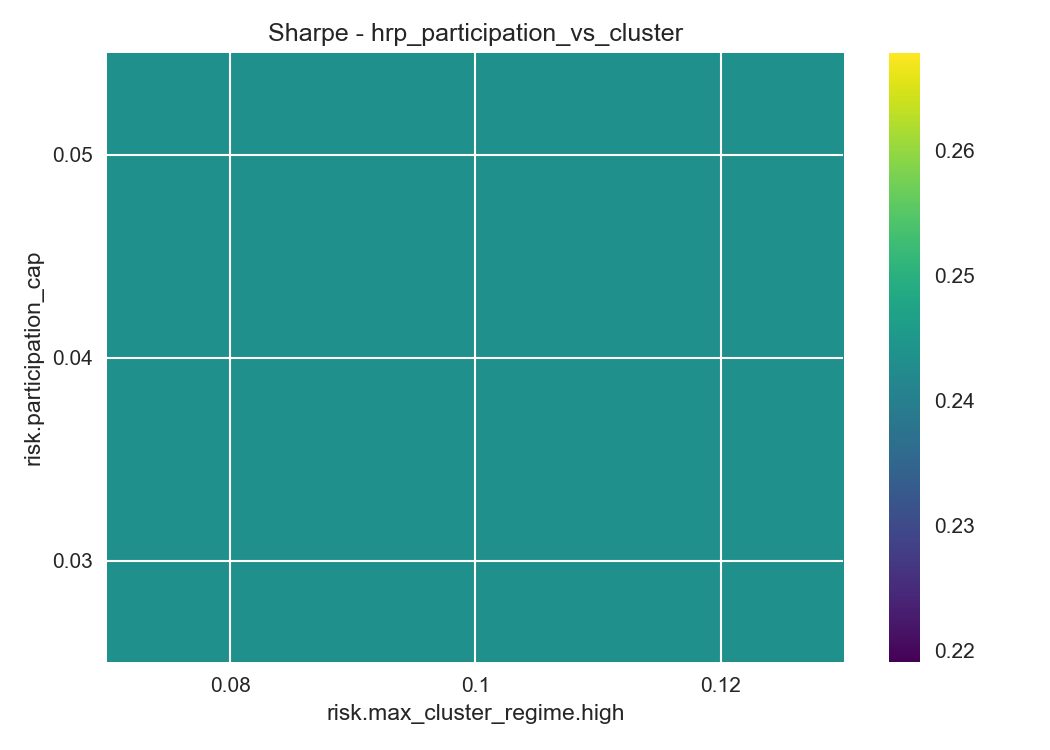

Max_Drawdown heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_participation_vs_cluster_max_drawdown_heatmap.png`

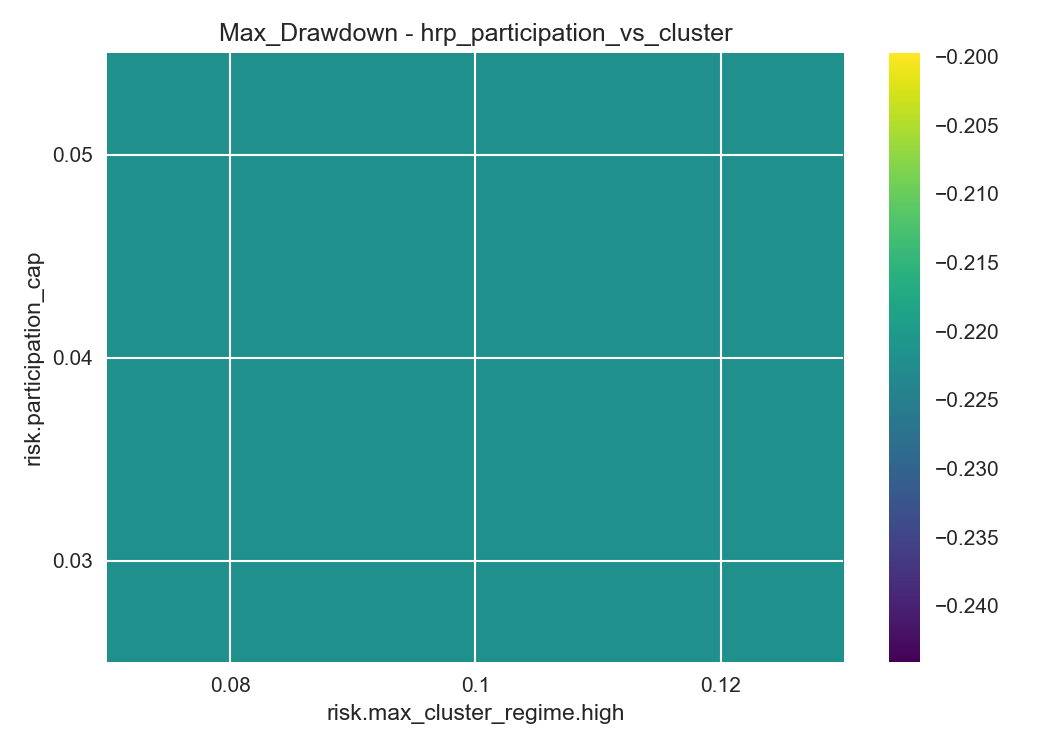

**Grid Target Vol Vs Turnover** - parametros ['risk.target_vol', 'risk.turnover_cap']

 - Backtest hrp_target_vol_vs_turnover | risk.target_vol=0.08, risk.turnover_cap=0.15


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1485)
Kill switch triggered on 2020-07-08 (vol=0.1330)
Kill switch triggered on 2020-10-05 (vol=0.1326)
Kill switch triggered on 2021-01-04 (vol=0.1302)
Kill switch triggered on 2021-02-22 (vol=0.1440)
Kill switch triggered on 2021-07-12 (vol=0.1282)
Kill switch triggered on 2021-10-04 (vol=0.1398)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


 - Backtest hrp_target_vol_vs_turnover | risk.target_vol=0.08, risk.turnover_cap=0.25


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1485)
Kill switch triggered on 2020-07-08 (vol=0.1330)
Kill switch triggered on 2020-10-05 (vol=0.1326)
Kill switch triggered on 2021-01-04 (vol=0.1302)
Kill switch triggered on 2021-02-22 (vol=0.1440)
Kill switch triggered on 2021-07-12 (vol=0.1289)
Kill switch triggered on 2021-10-04 (vol=0.1404)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


...

 - Backtest hrp_target_vol_vs_turnover | risk.target_vol=0.12, risk.turnover_cap=0.35


Kill switch triggered on 2020-02-26 (vol=0.2399)
Kill switch triggered on 2020-07-31 (vol=0.1956)
Kill switch triggered on 2021-01-29 (vol=0.1972)
Kill switch triggered on 2021-09-02 (mdd=-0.1296,vol=0.1962)
Kill switch triggered on 2021-11-04 (mdd=-0.1273)
Kill switch triggered on 2022-02-17 (vol=0.1926)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3462)
Kill switch triggered on 2022-09-05 (vol=0.1940)


Resultados salvos em c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_target_vol_vs_turnover_results.csv


,risk.target_vol,risk.turnover_cap,cagr,sharpe,vol,max_drawdown,calmar
4,0.10,0.25,0.149359,0.863843,0.172901,-0.207074,0.721286
3,0.10,0.15,0.136518,0.788991,0.173029,-0.228771,0.596745
5,0.10,0.35,0.107652,0.617026,0.174470,-0.272373,0.395239
0,0.08,0.15,0.059979,0.386679,0.155113,-0.221736,0.270497
1,0.08,0.25,0.059913,0.386113,0.155170,-0.221850,0.270061


Sharpe heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_target_vol_vs_turnover_sharpe_heatmap.png`

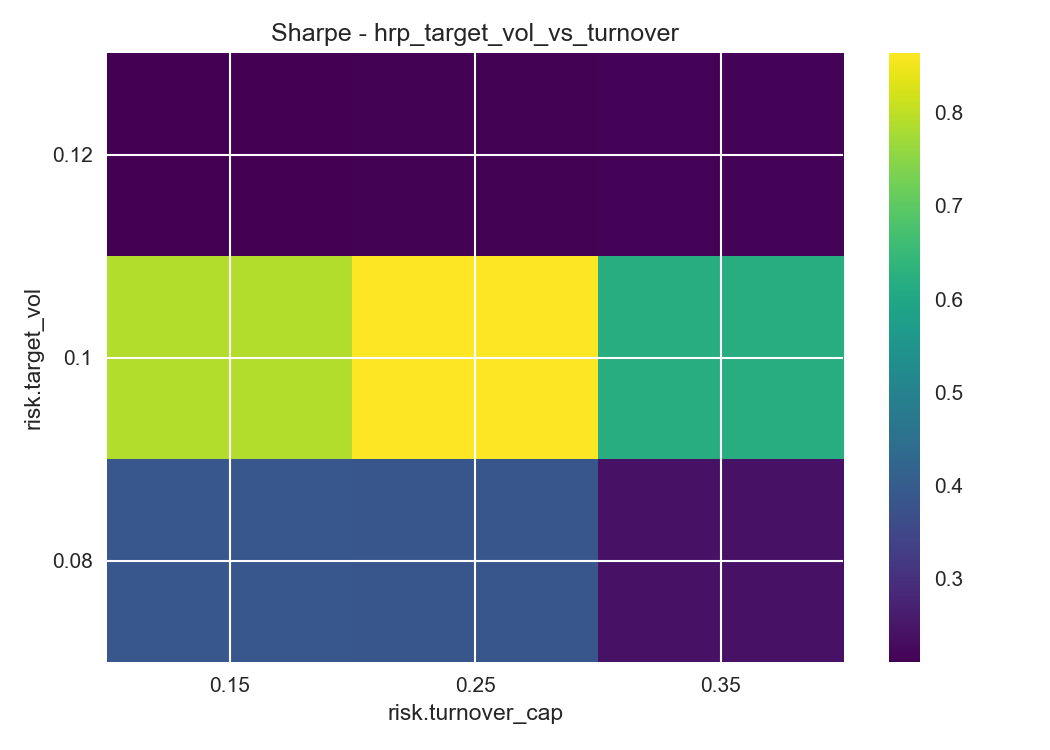

Max_Drawdown heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_target_vol_vs_turnover_max_drawdown_heatmap.png`

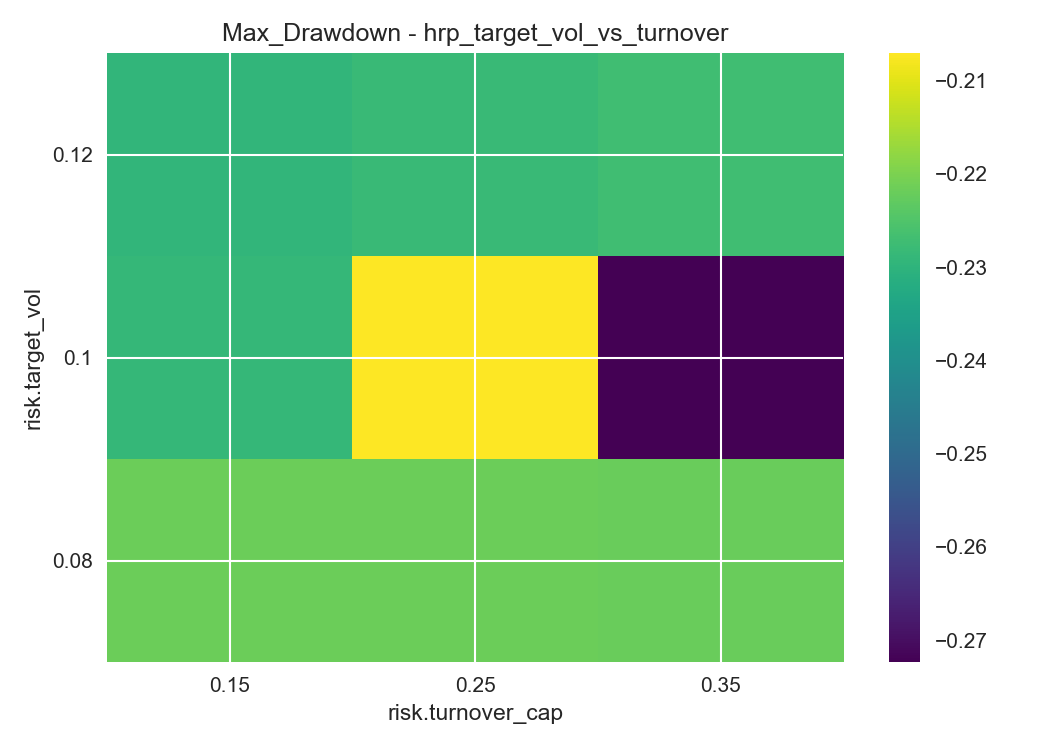

**Arquivos de heatmap (HRP / caps)**

,grid,metric,path
0,participation_vs_cluster,sharpe,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
1,participation_vs_cluster,max_drawdown,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
2,target_vol_vs_turnover,sharpe,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
3,target_vol_vs_turnover,max_drawdown,c:\Users\Cockles\Documents\GitHub\itau-quant-c...


In [11]:
hrp_grids = {
    "participation_vs_cluster": {
        "risk.participation_cap": [0.03, 0.04, 0.05],
        "risk.max_cluster_regime.high": [0.08, 0.10, 0.12],
    },
    "target_vol_vs_turnover": {
        "risk.target_vol": [0.08, 0.10, 0.12],
        "risk.turnover_cap": [0.15, 0.25, 0.35],
    },
}

hrp_runs = {}
for label, grid in hrp_grids.items():
    prefix = f"hrp_{label}"
    friendly = label.replace("_", " " ).title()
    display(Markdown(f"**Grid {friendly}** - parametros {list(grid.keys())}"))
    results_df, heatmaps = run_two_param_heatmaps(
        cfg,
        panel,
        grid,
        report_prefix=prefix,
        plot_metrics=("sharpe", "max_drawdown")
    )
    hrp_runs[label] = {"results": results_df, "heatmaps": heatmaps}
    display(results_df.sort_values("sharpe", ascending=False).head())
    for metric, path in heatmaps.items():
        display(Markdown(f"{metric.title()} heatmap: `{path}`"))
        display(Image(filename=str(path), width=420))

hrp_summary = pd.DataFrame(
    [
        {"grid": label, "metric": metric, "path": str(path)}
        for label, payload in hrp_runs.items()
        for metric, path in payload["heatmaps"].items()
    ]
)
display(Markdown("**Arquivos de heatmap (HRP / caps)**"))
display(hrp_summary)


## Grid Integrado de Risco
Combina target de volatilidade e limite de drawdown para avaliar consistencia das configuracoes recomendadas.

**Grid integrado** - parametros ['risk.target_vol', 'risk.mdd_thres']

 - Backtest risk_combo | risk.target_vol=0.07, risk.mdd_thres=-0.1


Kill switch triggered on 2020-02-11 (vol=0.1252)
Kill switch triggered on 2020-07-13 (vol=0.1242)
Kill switch triggered on 2021-01-08 (vol=0.1188)
Kill switch triggered on 2021-07-06 (vol=0.1125)
Kill switch triggered on 2021-10-04 (vol=0.1248)
Kill switch triggered on 2021-11-11 (vol=0.1215)
Kill switch triggered on 2022-02-08 (vol=0.1124)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3149)
Kill switch triggered on 2022-09-02 (vol=0.1915)


 - Backtest risk_combo | risk.target_vol=0.07, risk.mdd_thres=-0.12


Kill switch triggered on 2020-02-11 (vol=0.1252)
Kill switch triggered on 2020-07-13 (vol=0.1242)
Kill switch triggered on 2021-01-08 (vol=0.1188)
Kill switch triggered on 2021-07-06 (vol=0.1125)
Kill switch triggered on 2021-10-04 (vol=0.1248)
Kill switch triggered on 2021-11-11 (vol=0.1215)
Kill switch triggered on 2022-02-08 (vol=0.1124)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3149)
Kill switch triggered on 2022-09-02 (vol=0.1915)


...

Resultados salvos em c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\risk_combo_results.csv


,risk.target_vol,risk.mdd_thres,cagr,sharpe,vol,max_drawdown,calmar
6,0.09,-0.10,0.182932,1.306934,0.139970,-0.146688,1.24708
7,0.09,-0.12,0.182932,1.306934,0.139970,-0.146688,1.24708
8,0.09,-0.14,0.182932,1.306934,0.139970,-0.146688,1.24708
3,0.08,-0.10,0.037834,0.243405,0.155435,-0.221937,0.17047
4,0.08,-0.12,0.037834,0.243405,0.155435,-0.221937,0.17047


**Arquivos de heatmap (grid integrado)**

,metric,path
0,sharpe,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
1,max_drawdown,c:\Users\Cockles\Documents\GitHub\itau-quant-c...


Sharpe heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\risk_combo_sharpe_heatmap.png`

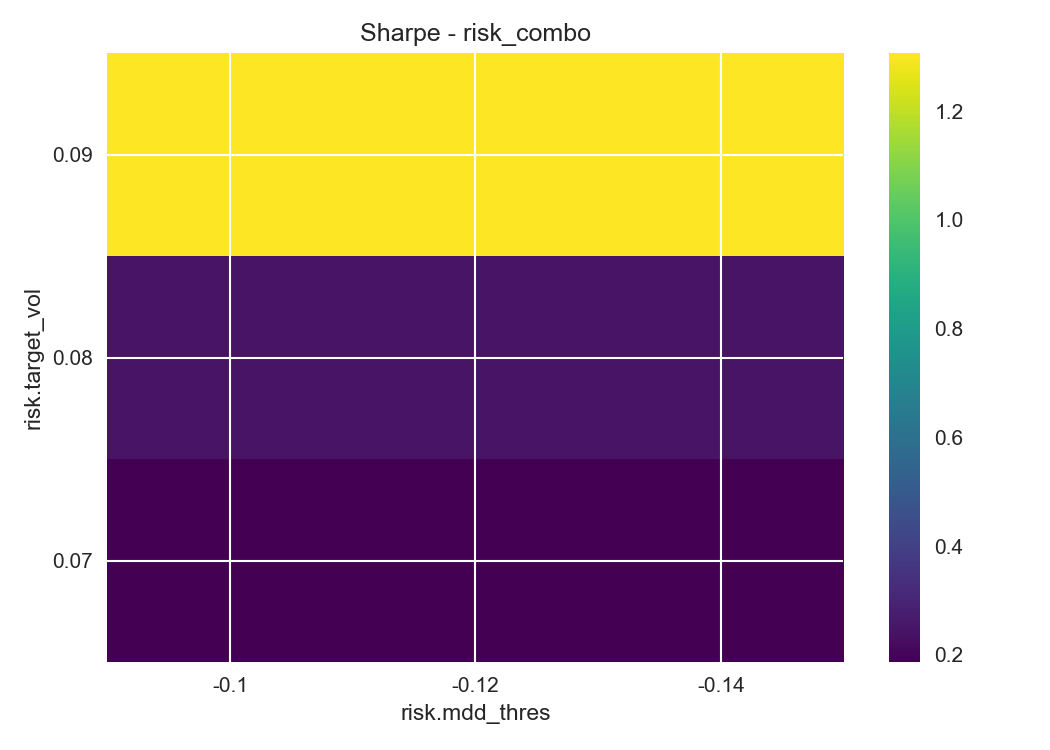

Max_Drawdown heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\risk_combo_max_drawdown_heatmap.png`

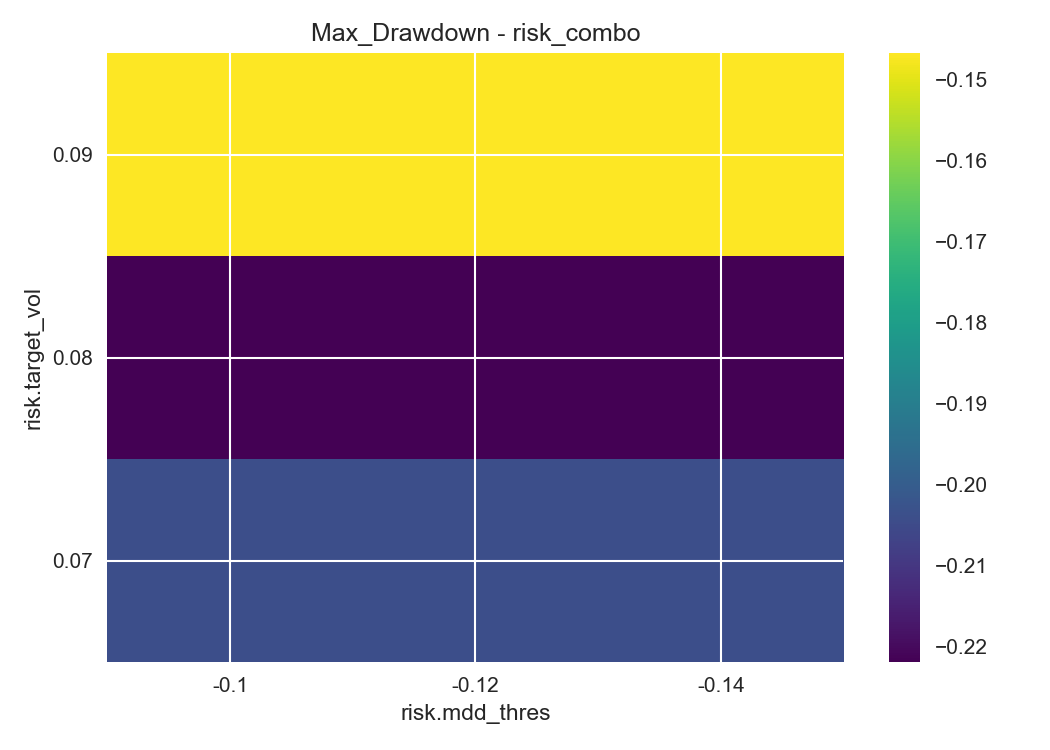

In [12]:
combined_grid = {
    "risk.target_vol": [0.07, 0.08, 0.09],
    "risk.mdd_thres": [-0.10, -0.12, -0.14],
}

display(Markdown(f"**Grid integrado** - parametros {list(combined_grid.keys())}"))
combined_results, combined_heatmaps = run_two_param_heatmaps(
    cfg,
    panel,
    combined_grid,
    report_prefix="risk_combo",
    plot_metrics=("sharpe", "max_drawdown")
)
display(combined_results.sort_values("sharpe", ascending=False).head())
combined_summary = pd.DataFrame(
    [
        {"metric": metric, "path": str(path)}
        for metric, path in combined_heatmaps.items()
    ]
)
display(Markdown("**Arquivos de heatmap (grid integrado)**"))
display(combined_summary)
for metric, path in combined_heatmaps.items():
    display(Markdown(f"{metric.title()} heatmap: `{path}`"))
    display(Image(filename=str(path), width=420))


## Relatorio PDF (Opcional)
Gera um PDF consolidado com figuras e caminhos dos artefatos.

In [13]:
# from reports.build_pdf import build_pdf
# 
# pdf_out = REPORTS_DIR / 'consolidated_report.pdf'
# build_pdf(CONFIG_PATH, pdf_out)
# print('PDF salvo em:', pdf_out)

## Proximos Passos
- Ajuste o grid de robustez (ex.: incluir `epsilon`, `n_cubes`, `overlap`).
- Tente diferentes periodos e universos no YAML.
- Compare estrategias alterando `factors.alphas` para diferentes pesos.
